<>:148: SyntaxWarning: invalid escape sequence '\s'
<>:157: SyntaxWarning: invalid escape sequence '\m'
<>:148: SyntaxWarning: invalid escape sequence '\s'
<>:157: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1140/2794527939.py:148: SyntaxWarning: invalid escape sequence '\s'
  ax1.axvline(1.25, color='purple', linestyle='-.', lw=1.5, alpha=0.6, label='Period-4 Bifurcation ($\sim 1.25$)')
/tmp/ipykernel_1140/2794527939.py:157: SyntaxWarning: invalid escape sequence '\m'
  text_str = "Autonomous System (Static $\mu$)\nExact Inverse Mapping ($f^{-1}$)\nNo Monte Carlo Noise\nBins = 5000"


🚀 启动【自治系统·精确反向乌拉姆】500点地毯式扫描...

进度         | 控制参数 μ       | R²       | 平均误差       | 耗时 (s)
-----------------------------------------------------------------
[  1/500]  | 1.2000       | 0.9886   | 5.0301     | 1.241s
[ 20/500]  | 1.2305       | 0.9942   | 3.7477     | 0.594s
[ 40/500]  | 1.2625       | 0.9589   | 10.6997    | 0.574s
[ 60/500]  | 1.2946       | 0.9900   | 4.7790     | 0.586s
[ 80/500]  | 1.3267       | 0.9932   | 3.9175     | 0.599s
[100/500]  | 1.3587       | 0.9879   | 5.0640     | 0.571s
[120/500]  | 1.3908       | 0.9876   | 5.2303     | 0.592s
[140/500]  | 1.4228       | 0.9897   | 4.8759     | 0.637s
[160/500]  | 1.4549       | 0.9887   | 5.1029     | 0.635s
[180/500]  | 1.4870       | 0.9867   | 5.6196     | 0.636s
[200/500]  | 1.5190       | 0.9870   | 5.3197     | 0.738s
[220/500]  | 1.5511       | 0.9926   | 3.9388     | 0.783s
[240/500]  | 1.5832       | 0.9823   | 6.4440     | 0.635s
[260/500]  | 1.6152       | 0.9838   | 6.3328     | 0.695s
[280/500]  | 1.64

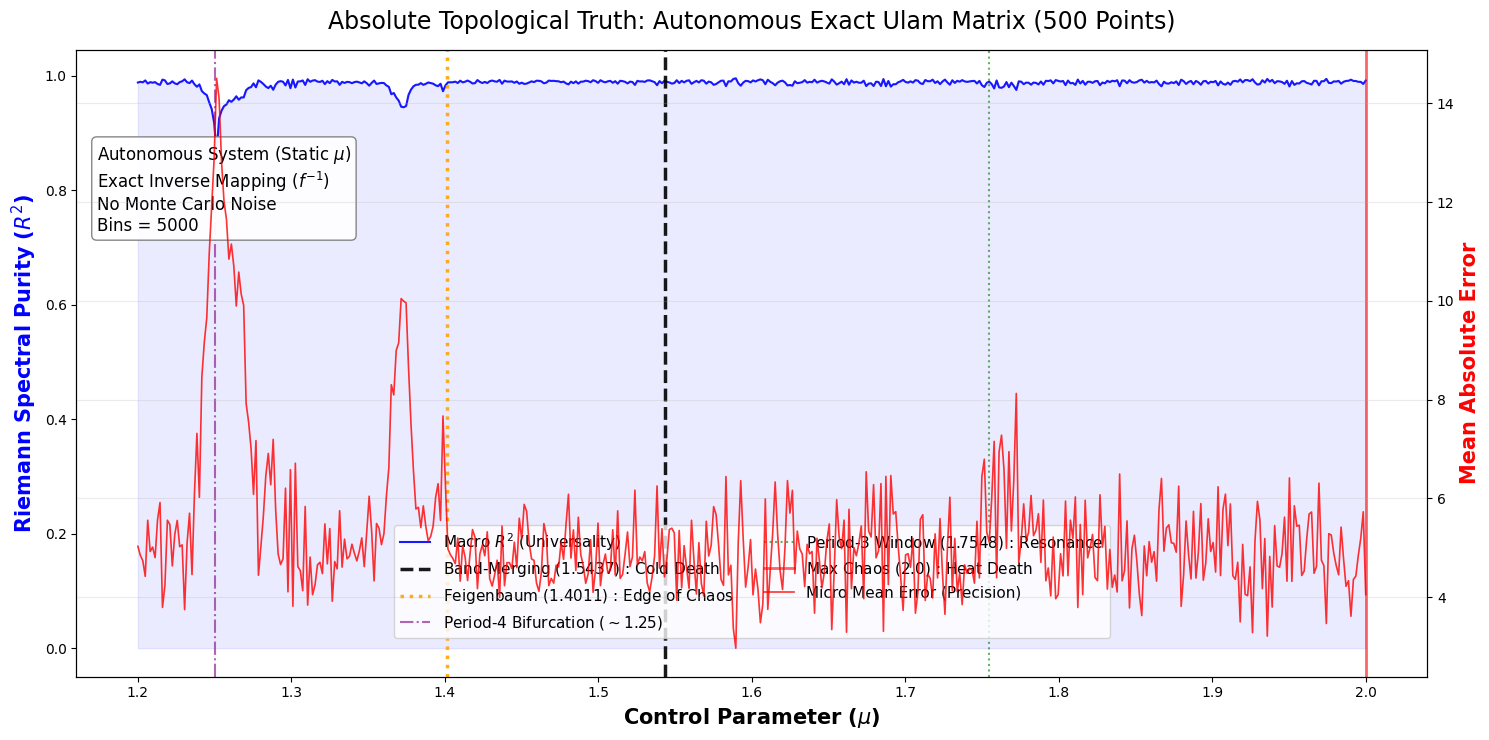

In [1]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import eigs
from scipy.stats import linregress
import mpmath
import matplotlib.pyplot as plt
import time
from numba import njit

# ================== 1. 真实的黎曼零点准备 ==================
mpmath.mp.dps = 15
N_ZEROS = 100
TRUE_ZEROS = np.array([float(mpmath.zetazero(i).imag) for i in range(1, N_ZEROS + 1)])

# ================== 2. 绝对精确的反向求逆转移矩阵 ==================
@njit
def build_exact_ulam_matrix_autonomous(n_bins, mu):
    """
    自治系统的终极解法：反向开根号求逆，严格计算几何重叠面积。
    时间复杂度大幅降低，因为每个 mu 只需构造一次矩阵。
    """
    P = np.zeros((n_bins, n_bins), dtype=np.float64)
    dx = 2.0 / n_bins
    
    # 遍历所有的目标格子 j（时光倒流的起点）
    for j in range(n_bins):
        y_low = -1.0 + j * dx
        y_high = -1.0 + (j + 1) * dx
        
        # 抛物线最高点为 1.0，超过 1.0 的目标区域没有任何概率流入
        if y_low >= 1.0:
            continue
            
        yh = min(1.0, y_high)
        yl = y_low
        
        # 🎯 核心绝杀：反向开根号，寻找源区间的两个“影子”
        # y = 1 - mu * x^2  ==>  x = \pm sqrt((1 - y) / mu)
        val_h = max(0.0, 1.0 - yh) / mu
        val_l = max(0.0, 1.0 - yl) / mu
        
        # 右侧影子区间 (x > 0)
        R_min = np.sqrt(val_h)
        R_max = np.sqrt(val_l)
        # 左侧影子区间 (x < 0)
        L_min = -R_max
        L_max = -R_min
        
        # --- 匹配右侧影子的源格子 i ---
        i_R_start = int((R_min + 1.0) / dx)
        i_R_end = int((R_max + 1.0) / dx)
        if i_R_start < 0: i_R_start = 0
        if i_R_end >= n_bins: i_R_end = n_bins - 1
            
        for i in range(i_R_start, i_R_end + 1):
            E_i = -1.0 + i * dx
            E_i_next = E_i + dx
            # 求源格子与影子区间的精确重叠长度
            overlap = min(E_i_next, R_max) - max(E_i, R_min)
            if overlap > 0.0:
                P[i, j] += overlap / dx  # 转移概率 = 重叠长度 / 源格子总长度
                
        # --- 匹配左侧影子的源格子 i ---
        i_L_start = int((L_min + 1.0) / dx)
        i_L_end = int((L_max + 1.0) / dx)
        if i_L_start < 0: i_L_start = 0
        if i_L_end >= n_bins: i_L_end = n_bins - 1
            
        for i in range(i_L_start, i_L_end + 1):
            E_i = -1.0 + i * dx
            E_i_next = E_i + dx
            overlap = min(E_i_next, L_max) - max(E_i, L_min)
            if overlap > 0.0:
                P[i, j] += overlap / dx

    return P

# ================== 3. 参数空间 500点 全景扫描 ==================
test_points = np.linspace(1.20, 2.00, 500)
N_BINS = 5000

results_R2 = []
results_mean_err = []

print(f"🚀 启动【自治系统·精确反向乌拉姆】500点地毯式扫描...\n")
print(f"{'进度':<10} | {'控制参数 μ':<12} | {'R²':<8} | {'平均误差':<10} | {'耗时 (s)'}")
print("-" * 65)

start_total_t = time.time()

for idx, mu in enumerate(test_points):
    start_point_t = time.time()
    
    # 一锤定音：直接构造永恒不变的精确转移矩阵
    trans_matrix = build_exact_ulam_matrix_autonomous(N_BINS, mu)
    
    # 转换为稀疏矩阵并确保严密的归一化
    P_sparse = sp.csr_matrix(trans_matrix, dtype=np.float64)
    row_sums = np.array(P_sparse.sum(axis=1)).flatten()
    row_sums[row_sums == 0] = 1.0 
    P_sparse.data /= row_sums[P_sparse.indices]
    
    try:
        eigenvalues, _ = eigs(P_sparse, k=N_ZEROS + 20, which='LM', tol=1e-4)
        phases = np.sort(np.angle(eigenvalues[np.abs(eigenvalues.imag) > 1e-4]))
        unwrapped = np.unwrap(phases)
        
        min_len = min(len(unwrapped), N_ZEROS)
        
        # 严格过滤，暴露自治系统周期区的绝对死寂
        if min_len > 10:
            unwrapped_trunc = unwrapped[:min_len]
            true_zeros_trunc = TRUE_ZEROS[:min_len]
            
            slope, intercept, r_val, _, _ = linregress(unwrapped_trunc, true_zeros_trunc)
            pred = slope * unwrapped_trunc + intercept
            err = np.mean(np.abs(pred - true_zeros_trunc))
            r2 = r_val**2
        else:
            err = 20.0 
            r2 = 0.0
            
    except Exception:
        err = 20.0
        r2 = 0.0
        
    results_R2.append(r2)
    results_mean_err.append(err)
    
    if (idx + 1) % 20 == 0 or idx == 0:
        elapsed = time.time() - start_point_t
        print(f"[{idx+1:>3d}/500]  | {mu:<12.4f} | {r2:<8.4f} | {err:<10.4f} | {elapsed:.3f}s")

print("-" * 65)
print(f"✅ 自治上帝视角扫描完成！总耗时: {(time.time()-start_total_t):.2f} 秒")

# ================== 4. 绝对物理真理相变图 ==================
fig, ax1 = plt.subplots(figsize=(15, 7.5))

ax1_twin = ax1.twinx()

ax1.plot(test_points, results_R2, 'b-', lw=1.5, alpha=0.9, label='Macro $R^2$ (Universality)')
ax1.fill_between(test_points, results_R2, color='blue', alpha=0.08)
ax1_twin.plot(test_points, results_mean_err, 'r-', lw=1.2, alpha=0.8, label='Micro Mean Error (Precision)')

ax1.axvline(1.543689, color='k', linestyle='--', lw=2.5, alpha=0.9, label='Band-Merging ($1.5437$) : Cold Death')
ax1.axvline(1.401155, color='orange', linestyle=':', lw=2.5, alpha=0.9, label='Feigenbaum ($1.4011$) : Edge of Chaos')
ax1.axvline(1.25, color='purple', linestyle='-.', lw=1.5, alpha=0.6, label='Period-4 Bifurcation ($\sim 1.25$)')
ax1.axvline(1.7548, color='green', linestyle=':', lw=1.5, alpha=0.6, label='Period-3 Window ($1.7548$) : Resonance')
ax1.axvline(2.0, color='red', linestyle='-', lw=2, alpha=0.6, label='Max Chaos ($2.0$) : Heat Death')

ax1.set_xlabel(r'Control Parameter ($\mu$)', fontsize=15, fontweight='bold')
ax1.set_ylabel(r'Riemann Spectral Purity ($R^2$)', color='b', fontsize=15, fontweight='bold')
ax1_twin.set_ylabel('Mean Absolute Error', color='r', fontsize=15, fontweight='bold')
ax1.set_title('Absolute Topological Truth: Autonomous Exact Ulam Matrix (500 Points)', fontsize=17, pad=15)

text_str = "Autonomous System (Static $\mu$)\nExact Inverse Mapping ($f^{-1}$)\nNo Monte Carlo Noise\nBins = 5000"
ax1.text(0.015, 0.85, text_str, transform=ax1.transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.95, edgecolor='gray'))

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower center', bbox_to_anchor=(0.5, 0.05), ncol=2, fontsize=11)

plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()